# 02 — Modélisation et Évaluation
## P01 - Prédiction du Churn TélécomGuinée
**Master 1 Fouille de Données — Université Kofi Annan de Guinée**

---
### Objectif
Comparer 3 algorithmes (Régression Logistique, Random Forest, XGBoost)
avec et sans rééquilibrage SMOTE. Sélectionner le meilleur modèle et
analyser le coût métier des erreurs.


In [16]:
# ── CONFIGURATION COLAB ─────────────────────────────────────────────────────
import os, sys
from google.colab import files
import pandas as pd
import io

# Créer tous les dossiers nécessaires
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('rapport', exist_ok=True)
os.makedirs('src', exist_ok=True)
print("✅ Dossiers créés")

# Uploader le dataset
print("\n📂 Sélectionne guinee_telecom_churn_FR.csv")
uploaded = files.upload()
df_init = pd.read_csv(io.BytesIO(uploaded['guinee_telecom_churn_FR.csv']))
df_init.to_csv('data/raw/guinee_telecom_churn_FR.csv', index=False)
print(f"✅ Dataset chargé : {df_init.shape[0]:,} lignes × {df_init.shape[1]} colonnes")

# Uploader preprocessing.py
print("\n📂 Sélectionne preprocessing.py")
uploaded2 = files.upload()
with open('src/preprocessing.py', 'wb') as f:
    f.write(uploaded2['preprocessing.py'])
print("✅ preprocessing.py sauvegardé")

# Ajouter src/ au path
sys.path.insert(0, 'src')
print("\n✅ Configuration terminée — tu peux lancer les autres cellules !")

✅ Dossiers créés

📂 Sélectionne guinee_telecom_churn_FR.csv


Saving guinee_telecom_churn_FR.csv to guinee_telecom_churn_FR.csv
✅ Dataset chargé : 15,000 lignes × 23 colonnes

📂 Sélectionne preprocessing.py


Saving preprocessing.py to preprocessing.py
✅ preprocessing.py sauvegardé

✅ Configuration terminée — tu peux lancer les autres cellules !


In [17]:

import sys, os
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import joblib

from preprocessing import load_data, encode_features, scale_features, split_data

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
print("Imports OK")


Imports OK


## 1. Préparation des données

In [18]:
# Chargement et encodage
df_raw  = load_data()
df_enc  = encode_features(df_raw)
df_enc, scaler = scale_features(df_enc, fit=True)

# Split sans SMOTE
X_train, X_test, y_train, y_test = split_data(df_enc)

# Split avec SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"Train (sans SMOTE) : {X_train.shape[0]:,} | Churn : {y_train.mean()*100:.1f}%")
print(f"Train (avec SMOTE) : {X_train_sm.shape[0]:,} | Churn : {y_train_sm.mean()*100:.1f}%")
print(f"Test               : {X_test.shape[0]:,}  | Churn : {y_test.mean()*100:.1f}%")


[load] 15000 lignes × 23 colonnes
[scale] Scaler sauvegardé → /content/drive/MyDrive/projet_churn/src/../models/scaler.joblib
[split] Train : 12000 | Test : 3000
Train (sans SMOTE) : 12,000 | Churn : 23.9%
Train (avec SMOTE) : 18,252 | Churn : 50.0%
Test               : 3,000  | Churn : 24.0%


## 2. Entraînement des modèles

In [19]:
models = {
    'Régression Logistique': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42,
        class_weight='balanced', n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=3, random_state=42, verbosity=0),
    'XGBoost + SMOTE': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0),
}

results = {}
trained = {}

for name, model in models.items():
    X_tr = X_train_sm if 'SMOTE' in name else X_train
    y_tr = y_train_sm if 'SMOTE' in name else y_train
    print(f"  Entraînement : {name}...", end=' ')
    model.fit(X_tr, y_tr)
    trained[name] = model
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred),  4),
        'Précision': round(precision_score(y_test, y_pred), 4),
        'Rappel':    round(recall_score(y_test, y_pred),    4),
        'F1-Score':  round(f1_score(y_test, y_pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba),  4),
    }
    print(f"F1={results[name]['F1-Score']}")

df_results = pd.DataFrame(results).T
print()
df_results


  Entraînement : Régression Logistique... F1=0.4047
  Entraînement : Random Forest... F1=0.3565
  Entraînement : XGBoost... F1=0.3556
  Entraînement : XGBoost + SMOTE... F1=0.1984



,Accuracy,Précision,Rappel,F1-Score,ROC-AUC
Régression Logistique,0.5930,0.3116,0.5772,0.4047,0.6372
Random Forest,0.6667,0.3317,0.3853,0.3565,0.6304
XGBoost,0.6750,0.3388,0.3741,0.3556,0.6295
XGBoost + SMOTE,0.7603,0.5000,0.1238,0.1984,0.6361


## 3. Tableau comparatif et visualisation

In [20]:
# Tableau avec mise en évidence du meilleur
print("="*65)
print(f"{'Modèle':<25} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6}")
print("-"*65)
best = df_results['F1-Score'].idxmax()
for name, row in df_results.iterrows():
    star = " ⭐" if name == best else ""
    print(f"{name:<25} {row['Accuracy']:>6} {row['Précision']:>6} "
          f"{row['Rappel']:>6} {row['F1-Score']:>6} {row['ROC-AUC']:>6}{star}")
print(f"\n Meilleur modèle : {best}")


Modèle                       Acc   Prec    Rec     F1    AUC
-----------------------------------------------------------------
Régression Logistique      0.593 0.3116 0.5772 0.4047 0.6372 ⭐
Random Forest             0.6667 0.3317 0.3853 0.3565 0.6304
XGBoost                    0.675 0.3388 0.3741 0.3556 0.6295
XGBoost + SMOTE           0.7603    0.5 0.1238 0.1984 0.6361

 Meilleur modèle : Régression Logistique


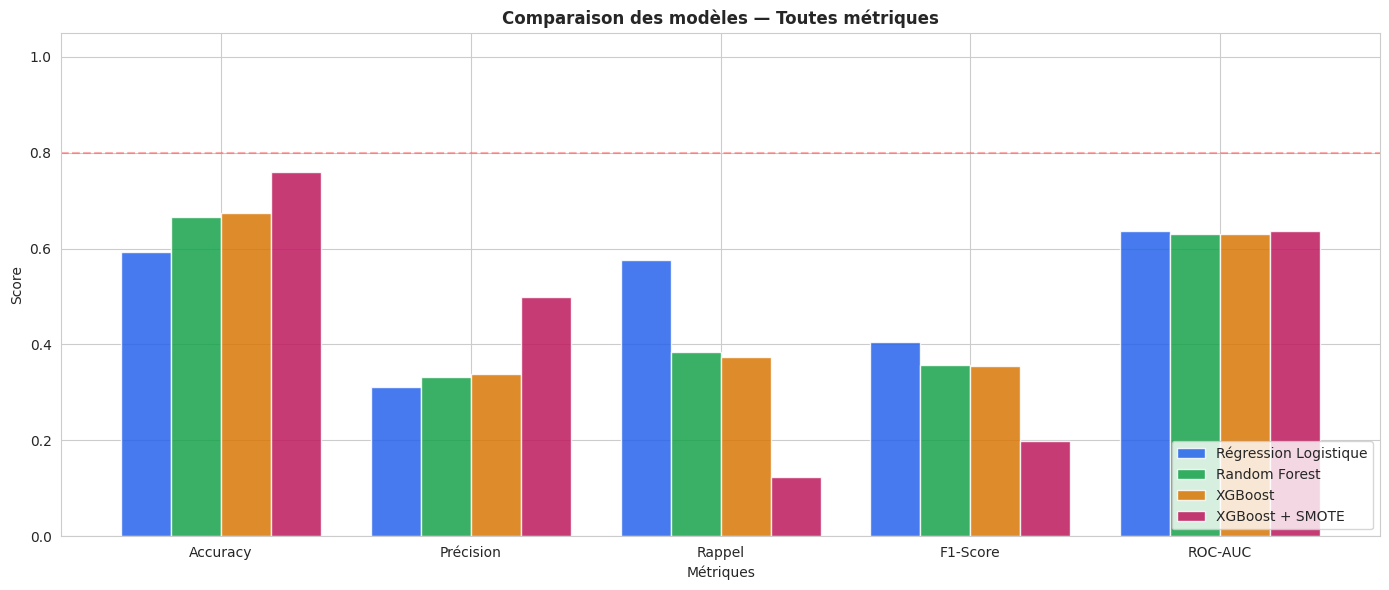

In [21]:
# Graphique comparatif en barres groupées
metrics = ['Accuracy', 'Précision', 'Rappel', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
colors = ['#2563EB', '#16A34A', '#D97706', '#BE185D']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, row) in enumerate(df_results.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metrics], width,
           label=name, color=colors[i], alpha=0.85)

ax.set_xlabel('Métriques')
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles — Toutes métriques', fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.3, label='Seuil 0.8')
plt.tight_layout()
plt.savefig('../rapport/fig06_comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Courbes ROC

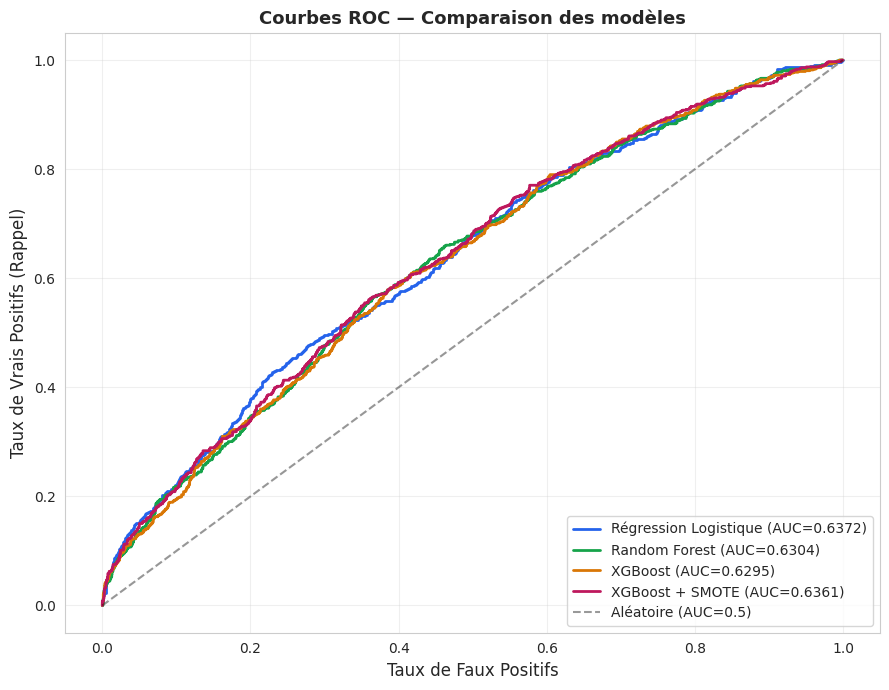

In [22]:
fig, ax = plt.subplots(figsize=(9, 7))
for i, (name, model) in enumerate(trained.items()):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=colors[i], linewidth=2,
            label=f'{name} (AUC={auc})')

ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Aléatoire (AUC=0.5)')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('Taux de Faux Positifs', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (Rappel)', fontsize=12)
ax.set_title('Courbes ROC — Comparaison des modèles', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../rapport/fig07_courbes_roc.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Matrices de confusion

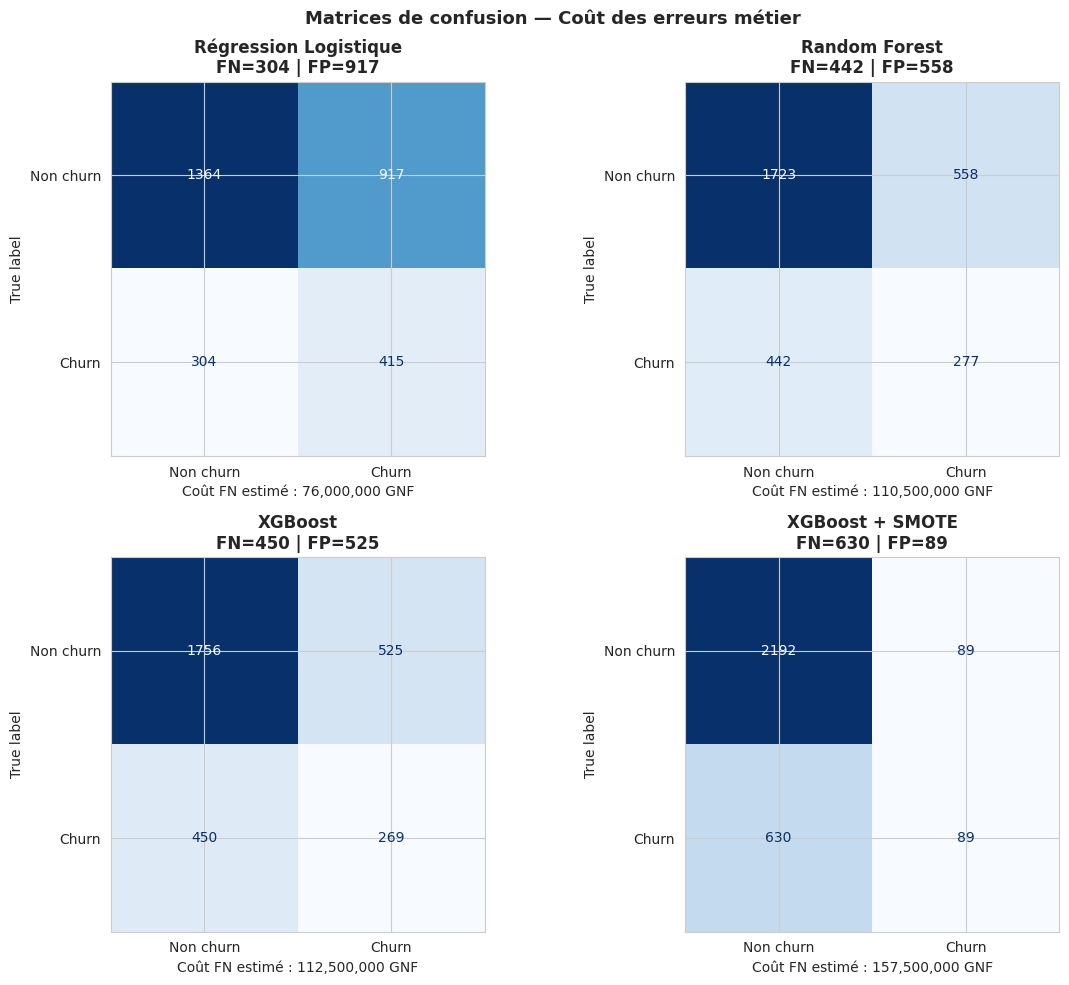

Interprétation métier :
  FN (churners manqués) → coût 250 000 GNF chacun (re-acquisition)
  FP (fidèles contactés) → coût 50 000 GNF chacun (offre inutile)


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non churn', 'Churn'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nFN={cm[1,0]} | FP={cm[0,1]}', fontweight='bold')
    fn_cost = cm[1,0] * 250000
    axes[i].set_xlabel(f'Coût FN estimé : {fn_cost:,} GNF')

plt.suptitle('Matrices de confusion — Coût des erreurs métier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../rapport/fig08_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interprétation métier :")
print("  FN (churners manqués) → coût 250 000 GNF chacun (re-acquisition)")
print("  FP (fidèles contactés) → coût 50 000 GNF chacun (offre inutile)")


## 6. Importance des variables (meilleur modèle)

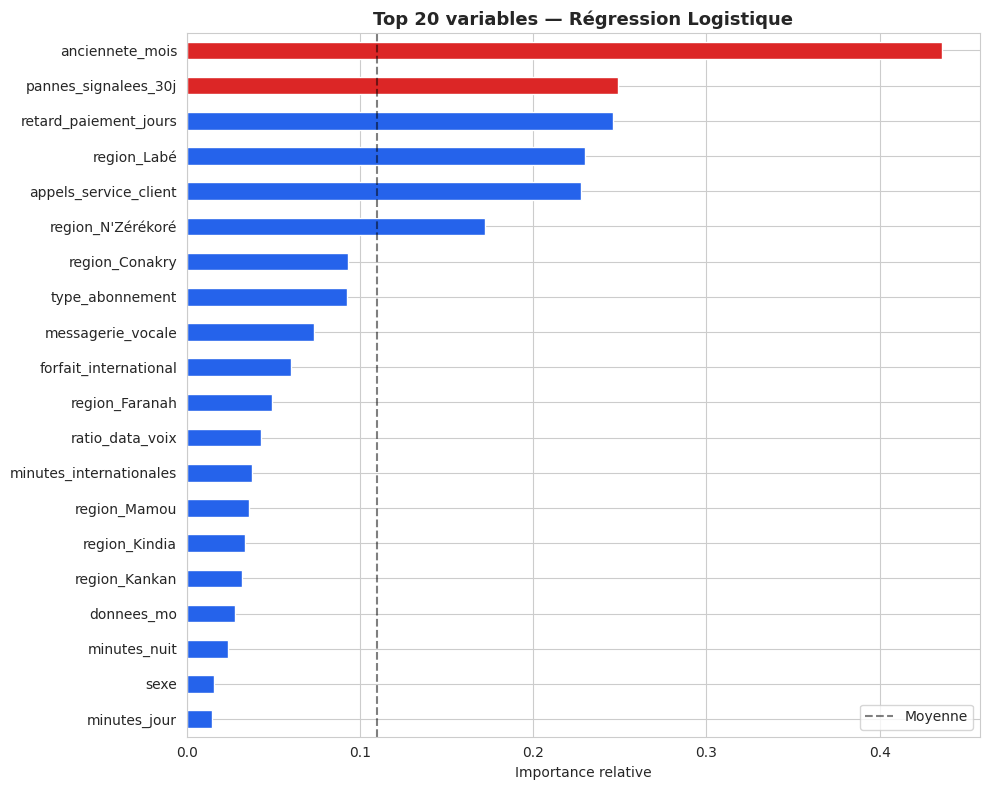


Top 10 variables les plus prédictives :
  anciennete_mois                     0.4361  ██████████████████████████████
  pannes_signalees_30j                0.2487  █████████████████
  retard_paiement_jours               0.2461  ████████████████
  region_Labé                         0.2301  ███████████████
  appels_service_client               0.2273  ███████████████
  region_N'Zérékoré                   0.1723  ███████████
  region_Conakry                      0.0930  ██████
  type_abonnement                     0.0923  ██████
  messagerie_vocale                   0.0736  █████
  forfait_international               0.0598  ████


In [24]:
best_model = trained[best]

if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importance = np.abs(best_model.coef_[0])

fi = pd.Series(importance, index=X_train.columns).sort_values(ascending=True)
top20 = fi.tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors_fi = ['#dc2626' if 'reclamation' in v or 'panne' in v or 'anciennete' in v
             else '#2563EB' for v in top20.index]
top20.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
ax.set_title(f'Top 20 variables — {best}', fontweight='bold', fontsize=13)
ax.set_xlabel("Importance relative")
ax.axvline(x=top20.mean(), color='black', linestyle='--', alpha=0.5, label='Moyenne')
ax.legend()
plt.tight_layout()
plt.savefig('../rapport/fig09_importance_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 variables les plus prédictives :")
for col, val in fi.tail(10).sort_values(ascending=False).items():
    bar = '█' * int(val / fi.max() * 30)
    print(f"  {col:<35} {val:.4f}  {bar}")


## 7. Sauvegarde du meilleur modèle

In [25]:
import json, os

os.makedirs('../models', exist_ok=True)

# Sauvegarder tous les modèles
for name, model in trained.items():
    fname = name.replace(' ', '_').replace('+', 'SMOTE')
    path = f'../models/{fname}.joblib'
    joblib.dump(model, path)
    print(f"  Sauvegardé : {path}")

# Meilleur modèle
joblib.dump(trained[best], '../models/best_model.joblib')
print(f"\n✅ Meilleur modèle ({best}) → ../models/best_model.joblib")

# Résultats JSON
clean = {k: {m: v for m, v in r.items()} for k, r in results.items()}
with open('../models/resultats_modeles.json', 'w') as f:
    json.dump(clean, f, indent=2, ensure_ascii=False)
print("✅ Résultats JSON → ../models/resultats_modeles.json")


  Sauvegardé : ../models/Régression_Logistique.joblib
  Sauvegardé : ../models/Random_Forest.joblib
  Sauvegardé : ../models/XGBoost.joblib
  Sauvegardé : ../models/XGBoost_SMOTE_SMOTE.joblib

✅ Meilleur modèle (Régression Logistique) → ../models/best_model.joblib
✅ Résultats JSON → ../models/resultats_modeles.json


## 8. Synthèse et recommandations métier

In [26]:
print("=" * 65)
print("SYNTHÈSE — P01 Churn TélécomGuinée")
print("=" * 65)
print()
print("MEILLEUR MODÈLE :", best)
print()
best_r = results[best]
print(f"  Accuracy  : {best_r['Accuracy']}")
print(f"  Précision : {best_r['Précision']}")
print(f"  Rappel    : {best_r['Rappel']}")
print(f"  F1-Score  : {best_r['F1-Score']}")
print(f"  ROC-AUC   : {best_r['ROC-AUC']}")
print()
print("RECOMMANDATIONS MÉTIER :")
print("  - Score 60-75% → SMS automatique offre data bonus")
print("  - Score 75-88% → SMS + notification application")
print("  - Score  > 88% → Appel conseiller + remise personnalisée")
print()
print("LIMITES :")
print("  - Dataset synthétique → valider sur données réelles Orange Guinée")
print("  - Réentraîner le modèle chaque mois avec les nouvelles données")
print("  - Ajouter les données CDR temps réel pour scoring journalier")
print()
print("=> Déploiement : streamlit run app/app.py")


SYNTHÈSE — P01 Churn TélécomGuinée

MEILLEUR MODÈLE : Régression Logistique

  Accuracy  : 0.593
  Précision : 0.3116
  Rappel    : 0.5772
  F1-Score  : 0.4047
  ROC-AUC   : 0.6372

RECOMMANDATIONS MÉTIER :
  - Score 60-75% → SMS automatique offre data bonus
  - Score 75-88% → SMS + notification application
  - Score  > 88% → Appel conseiller + remise personnalisée

LIMITES :
  - Dataset synthétique → valider sur données réelles Orange Guinée
  - Réentraîner le modèle chaque mois avec les nouvelles données
  - Ajouter les données CDR temps réel pour scoring journalier

=> Déploiement : streamlit run app/app.py
